# 15-Plot In Plotly

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px


In [4]:
# import/load dataset of iris
df = sns.load_dataset('iris')
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## Scatter Plot

In [7]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [9]:
fig1 = px.scatter(df, x='sepal_length', y='sepal_width', color='species')
fig1.show()

# save  the plot
fig1.write_image('./outputs/fig1.png', scale=3)

# 2. Line Plot

In [13]:
# sort the dataset
df_line = df.sort_values(by=['species', 'sepal_length'])

fig2 = px.line(df_line, x='sepal_length', y='sepal_width', color='species')
fig2.show()

# sve the plot
fig2.write_image('./outputs/fig2.png', scale=3)

# 3.Bar-Plot

In [18]:
# group values based on means
df_bar = df.groupby(['species']).mean().reset_index()
df_bar.head()

,species,sepal_length,sepal_width,petal_length,petal_width
0,setosa,5.006,3.428,1.462,0.246
1,versicolor,5.936,2.770,4.260,1.326
2,virginica,6.588,2.974,5.552,2.026


In [23]:
fig3 = px.bar(df_bar, x='species', y='sepal_length')
fig3.show()

# save the plot
fig3.write_image('./outputs/fig3.png', scale=3)

<Axes: xlabel='species', ylabel='sepal_length'>

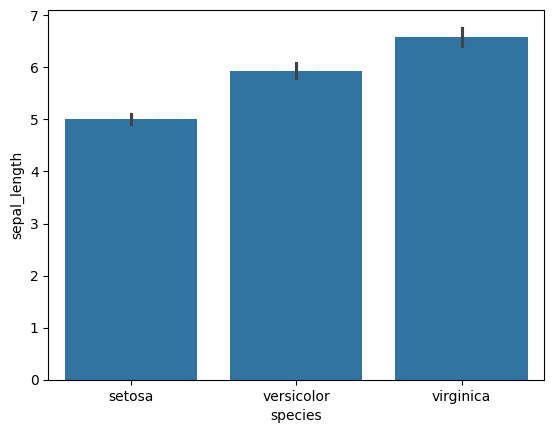

In [22]:
# seaborn does not need to make means groups

sns.barplot(data=df, x='species', y='sepal_length')

# Box-Plot

In [25]:
# box plot
fig4 = px.box(df, x='species', y='sepal_length', color='species')
fig4.show()

# save the plot
fig4.write_image('./outputs/fig4.png', scale=3)

In [27]:
# Violin Plot
fig5 = px.violin(df, x='species', y='sepal_length', color='species', box=True)
fig5.show()

# save the plot
fig5.write_image('./outputs/fig5.png', scale=3)

In [29]:
# Histogram 
fig6 = px.histogram(df, x='sepal_width', color='species')
fig6.show()

# save the plot
fig6.write_image('./outputs/fig6.png', scale=3)

In [32]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [ ]:
# 7 Pie chart
df_pie = df['species'].value_counts().reset_index()
df_pie.columns = ['species', 'count']

fig7 = px.pie(df_pie, names='species', values='count')
fig7.show()

# save the plot
fig7.write_image('./outputs/fig7.png', scale=3)

In [40]:
# 8 3D scatter Plot
fig8 = px.scatter_3d(df, x='sepal_length', y='sepal_width', z='petal_length', color='species')
fig8.show() 

# save the plot
fig8.write_html('./outputs/fig8.html')

In [43]:
# 9 Area plot

# sort the dataset
df_area = df.sort_values(by=['sepal_length'])

fig9 = px.area(df_area, x='sepal_width', y='sepal_length', color='species')
fig9.show()

# save the plot
fig9.write_image('./outputs/fig9.png', scale=3)

In [45]:
# bubble plot
fig10 = px.scatter(df, x='sepal_length', y='sepal_width', size='petal_length', color='species')
fig10.show()
# save the plot
fig10.write_image('./outputs/fig10.png', scale=3)

In [49]:
# 11 sunburst chart

df_sunburst = df.groupby(['species', 'petal_width']).size().reset_index(name='counts')

fig11 = px.sunburst(df_sunburst, path=['species', 'petal_width'], values='counts')
fig11.show()

# save the plot
fig11.write_image('./outputs/fig11.png', scale=3)

# save the plots in one html file
fig11.write_html('./outputs/all_plots.html')
    

In [53]:
# 12 Parallel coordinates plot

# Add a numeric species_id based on species names for coloring
df['species_id'] = df['species'].astype('category').cat.codes

fig12 = px.parallel_coordinates(df, color='species_id', labels={'species_id': 'species'})
fig12.show()

# save the plot
fig12.write_image('./outputs/fig12.png', scale=3)

# save the plot in html format
fig12.write_html('./outputs/fig12.html')

In [55]:
# 13 Density contour plot

fig13 = px.density_contour(df, x='sepal_length', y='sepal_width', color='species')
fig13.show()

# save the plot
fig13.write_image('./outputs/fig13.png', scale=3)

In [70]:
# 14 Ternary plot
fig14 = px.scatter_ternary(df, a='sepal_length', b='sepal_width', c='petal_width', color='species')
fig14.show()

In [93]:
# 15 Polar Chart (Radar chart)

df_polar = df.groupby(['species']).mean().reset_index()

fig15 = px.line_polar( df_polar, r='sepal_width', theta='species', line_close=True)
fig15.show()

# save the plot
fig15.write_image('./outputs/fig15.png', scale=3)